In [1]:
# для установки библиотеки ETNA в консоли следует применить
# pip install git+https://github.com/etna-team/etna.git#egg=etna[all]
# так как библиотека давно исключена из pip как устаревшая и/или небезопасная

# Data Preparation

In [2]:
import pandas as pd

from etna.datasets.tsdataset import TSDataset
from etna.transforms import (
    StandardScalerTransform,
    MeanTransform,
    LagTransform,
    DateFlagsTransform,
    BoxCoxTransform,
    HolidayTransform)


from etna.pipeline import Pipeline, AutoRegressivePipeline
from etna.metrics import SMAPE

import warnings
import numpy as np
import random

from numpy.f2py.crackfortran import verbose

warnings.filterwarnings('ignore')

from etna.analysis import plot_forecast

def set_seed(seed: int = 42):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)

set_seed()
smape = SMAPE()

/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
HORIZON = 90
CONSIDER_SHOP = [1, 2, 3]
SEGMENTS_TO_SHOW = ['3 + 27' , '1 + 47'] # просто рандомные сегменты для построения графика прогноза


In [4]:
def train_and_evaluate_model(ts,
                             model,
                             transforms,
                             horizon,
                             metrics,
                             is_auto_regressive = False,
                             print_metrics=True,
                             return_forecast=False,
                             n_train_samples = 360 * 2,
                             segments_to_plot=SEGMENTS_TO_SHOW,
                         ):
    """"
    Обучает модель, вычисляет прогнозы для
    тестовой выборки и строит график прогнозов.
    """

    import copy

    ts_copy = copy.deepcopy(ts)
    train_ts, test_ts = ts_copy.train_test_split(test_size=horizon)

    if not is_auto_regressive:
        pipe = Pipeline(model=model,
                        transforms=transforms,
                        horizon=horizon)

    else:
        pipe = AutoRegressivePipeline(model = model,
                                      transforms=transforms,
                                      horizon=horizon)

    pipe.fit(train_ts)
    forecast_ts = pipe.forecast()

    # оцениваем качество прогнозов по сегментам
    segment_metrics = metrics(test_ts, forecast_ts)
    segment_metrics = pd.Series(segment_metrics)

    avg_metric = sum(segment_metrics) / len(segment_metrics)

    if print_metrics:
        print(f"Avg (by segments) metric {metrics} is: {avg_metric}")

    if segments_to_plot:
        plot_forecast(forecast_ts, test_ts,
                      train_ts, n_train_samples=n_train_samples, segments=segments_to_plot)

    if return_forecast:
        return segment_metrics, avg_metric, forecast_ts

    return segment_metrics, avg_metric

In [5]:
df = pd.read_csv('HW_train.csv', parse_dates=['date'])

df.rename(columns={'date': 'timestamp',
                   'sales': 'target'}, inplace=True)
df

,timestamp,store,item,target
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [6]:
# уменьшаем размер данных, чтобы не тратить много времени на обучение
before_shape = df.shape
print('before', before_shape)
df = df[df.store.isin(CONSIDER_SHOP)]
print('before', df.shape)

print(f"Current dataset size {df.shape[0] * 100 / before_shape[0]}%")

before (913000, 4)
before (273900, 4)
Current dataset size 30.0%


In [7]:
df_new = pd.read_csv('HW_test.csv', parse_dates=['date'])
df_new = df_new[df_new.store.isin(CONSIDER_SHOP)]

df_new.rename(columns={'date': 'timestamp',
                   'sales': 'target'}, inplace=True)


df_new.drop(columns='id', inplace=True)

df_new

,timestamp,store,item
0,2018-01-01,1,1
1,2018-01-02,1,1
2,2018-01-03,1,1
3,2018-01-04,1,1
4,2018-01-05,1,1
...,...,...,...
44365,2018-03-27,3,50
44366,2018-03-28,3,50
44367,2018-03-29,3,50
44368,2018-03-30,3,50


In [8]:
df['segment'] = (df['store'].astype(str) + ' + '
                 + df['item'].astype(str))

df_new['segment'] = (df_new['store'].astype(str) + ' + '
                     + df_new['item'].astype(str))

df.head()

,timestamp,store,item,target,segment
0,2013-01-01,1,1,13,1 + 1
1,2013-01-02,1,1,11,1 + 1
2,2013-01-03,1,1,14,1 + 1
3,2013-01-04,1,1,13,1 + 1
4,2013-01-05,1,1,10,1 + 1


In [9]:
for col in ['store', 'item']:
    df[col] = df[col].astype('category')
    df_new[col] = df_new[col].astype('category')

In [10]:
regressor_df = df[['timestamp', 'segment', 'store', 'item']].copy()
regressor_df

,timestamp,segment,store,item
0,2013-01-01,1 + 1,1,1
1,2013-01-02,1 + 1,1,1
2,2013-01-03,1 + 1,1,1
3,2013-01-04,1 + 1,1,1
4,2013-01-05,1 + 1,1,1
...,...,...,...,...
900213,2017-12-27,3 + 50,3,50
900214,2017-12-28,3 + 50,3,50
900215,2017-12-29,3 + 50,3,50
900216,2017-12-30,3 + 50,3,50


In [11]:
# экзогенные переменные store и item
regressor_df_new = df_new.copy()
regressor_df_new

,timestamp,store,item,segment
0,2018-01-01,1,1,1 + 1
1,2018-01-02,1,1,1 + 1
2,2018-01-03,1,1,1 + 1
3,2018-01-04,1,1,1 + 1
4,2018-01-05,1,1,1 + 1
...,...,...,...,...
44365,2018-03-27,3,50,3 + 50
44366,2018-03-28,3,50,3 + 50
44367,2018-03-29,3,50,3 + 50
44368,2018-03-30,3,50,3 + 50


In [12]:
regressor_df = regressor_df.sort_index(
    axis=1, ascending=False)

regressor_df_new = regressor_df_new.sort_index(
    axis=1, ascending=False)

In [13]:
regressor_df.shape, regressor_df_new.shape, regressor_df.shape[0] + regressor_df_new.shape[0]

((273900, 4), (13500, 4), 287400)

In [14]:
regressor_df.columns, regressor_df_new.columns

(Index(['timestamp', 'store', 'segment', 'item'], dtype='object'),
 Index(['timestamp', 'store', 'segment', 'item'], dtype='object'))

In [15]:
regressor_df = pd.concat([regressor_df, regressor_df_new], axis=0)

regressor_df['quarter'] = regressor_df['timestamp'].dt.quarter
regressor_df['quarter_start'] = regressor_df['timestamp'].dt.is_quarter_start
regressor_df['quarter_end'] = regressor_df['timestamp'].dt.is_quarter_end
regressor_df

,timestamp,store,segment,item,quarter,quarter_start,quarter_end
0,2013-01-01,1,1 + 1,1,1,True,False
1,2013-01-02,1,1 + 1,1,1,False,False
2,2013-01-03,1,1 + 1,1,1,False,False
3,2013-01-04,1,1 + 1,1,1,False,False
4,2013-01-05,1,1 + 1,1,1,False,False
...,...,...,...,...,...,...,...
44365,2018-03-27,3,3 + 50,50,1,False,False
44366,2018-03-28,3,3 + 50,50,1,False,False
44367,2018-03-29,3,3 + 50,50,1,False,False
44368,2018-03-30,3,3 + 50,50,1,False,False


In [16]:
# подготавливаем исторический набор эндогенных переменных
df.drop(['store', 'item'], axis=1, inplace=True)
df

,timestamp,target,segment
0,2013-01-01,13,1 + 1
1,2013-01-02,11,1 + 1
2,2013-01-03,14,1 + 1
3,2013-01-04,13,1 + 1
4,2013-01-05,10,1 + 1
...,...,...,...
900213,2017-12-27,52,3 + 50
900214,2017-12-28,75,3 + 50
900215,2017-12-29,68,3 + 50
900216,2017-12-30,62,3 + 50


In [17]:
df = TSDataset.to_dataset(df)
df

segment,1 + 1,1 + 10,1 + 11,1 + 12,1 + 13,1 + 14,1 + 15,1 + 16,1 + 17,1 + 18,...,3 + 46,3 + 47,3 + 48,3 + 49,3 + 5,3 + 50,3 + 6,3 + 7,3 + 8,3 + 9
feature,target,target,target,target,target,target,target,target,target,target,...,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13.0,37.0,37.0,33.0,37.0,22.0,42.0,14.0,13.0,38.0,...,33.0,10.0,28.0,21.0,13.0,45.0,34.0,40.0,54.0,28.0
2013-01-02,11.0,34.0,43.0,35.0,31.0,35.0,33.0,11.0,18.0,51.0,...,46.0,12.0,32.0,14.0,9.0,47.0,38.0,36.0,34.0,16.0
2013-01-03,14.0,32.0,34.0,41.0,50.0,26.0,45.0,12.0,15.0,42.0,...,37.0,13.0,40.0,22.0,10.0,39.0,32.0,36.0,61.0,32.0
2013-01-04,13.0,45.0,52.0,45.0,45.0,32.0,39.0,15.0,19.0,50.0,...,32.0,5.0,39.0,26.0,20.0,48.0,36.0,38.0,38.0,40.0
2013-01-05,10.0,35.0,45.0,46.0,49.0,31.0,47.0,22.0,16.0,56.0,...,41.0,14.0,47.0,22.0,13.0,46.0,36.0,31.0,54.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,14.0,55.0,43.0,47.0,49.0,42.0,62.0,16.0,29.0,54.0,...,60.0,21.0,42.0,23.0,17.0,52.0,53.0,53.0,67.0,46.0
2017-12-28,19.0,63.0,64.0,49.0,68.0,51.0,82.0,24.0,13.0,69.0,...,72.0,19.0,52.0,38.0,21.0,75.0,55.0,53.0,80.0,61.0


In [18]:
regressor_df = TSDataset.to_dataset(regressor_df)
regressor_df

segment    1 + 1                                         1 + 10          \
feature     item quarter quarter_end quarter_start store   item quarter   
timestamp                                                                 
2013-01-01     1       1       False          True     1     10       1   
2013-01-02     1       1       False         False     1     10       1   
2013-01-03     1       1       False         False     1     10       1   
2013-01-04     1       1       False         False     1     10       1   
2013-01-05     1       1       False         False     1     10       1   
...          ...     ...         ...           ...   ...    ...     ...   
2018-03-27     1       1       False         False     1     10       1   
2018-03-28     1       1       False         False     1     10       1   
2018-03-29     1       1       False         False     1     10       1   
2018-03-30     1       1       False         False     1     10       1   
2018-03-31     1       1        True         False     1     10       1   

segment                                     ... 3 + 8                      \
feature    quarter_end quarter_start store  ...  item quarter quarter_end   
timestamp                                   ...                             
2013-01-01       False          True     1  ...     8       1       False   
2013-01-02       False         False     1  ...     8       1       False   
2013-01-03       False         False     1  ...     8       1       False   
2013-01-04       False         False     1  ...     8       1       False   
2013-01-05       False         False     1  ...     8       1       False   
...                ...           ...   ...  ...   ...     ...         ...   
2018-03-27       False         False     1  ...     8       1       False   
2018-03-28       False         False     1  ...     8       1       False   
2018-03-29       False         False     1  ...     8       1       False   
2018-03-30       False         False     1  ...     8       1       False   
2018-03-31        True         False     1  ...     8       1        True   

segment                        3 + 9                                          
feature    quarter_start store  item quarter quarter_end quarter_start store  
timestamp                                                                     
2013-01-01          True     3     9       1       False          True     3  
2013-01-02         False     3     9       1       False         False     3  
2013-01-03         False     3     9       1       False         False     3  
2013-01-04         False     3     9       1       False         False     3  
2013-01-05         False     3     9       1       False         False     3  
...                  ...   ...   ...     ...         ...           ...   ...  
2018-03-27         False     3     9       1       False         False     3  
2018-03-28         False     3     9       1       False         False     3  
2018-03-29         False     3     9       1       False         False     3  
2018-03-30         False     3     9       1       False         False     3  
2018-03-31         False     3     9       1        True         False     3  

[1916 rows x 750 columns]

In [19]:
# создаём объединённый набор
ts = TSDataset(df=df, freq='D', df_exog=regressor_df,
               known_future='all')
ts

segment    1 + 1                                                1 + 10  \
feature     item quarter quarter_end quarter_start store target   item   
timestamp                                                                
2013-01-01     1       1       False          True     1   13.0     10   
2013-01-02     1       1       False         False     1   11.0     10   
2013-01-03     1       1       False         False     1   14.0     10   
2013-01-04     1       1       False         False     1   13.0     10   
2013-01-05     1       1       False         False     1   10.0     10   
...          ...     ...         ...           ...   ...    ...    ...   
2017-12-27     1       4       False         False     1   14.0     10   
2017-12-28     1       4       False         False     1   19.0     10   
2017-12-29     1       4       False         False     1   15.0     10   
2017-12-30     1       4       False         False     1   27.0     10   
2017-12-31     1       4        True         False     1   23.0     10   

segment                                       ...       3 + 8                \
feature    quarter quarter_end quarter_start  ... quarter_end quarter_start   
timestamp                                     ...                             
2013-01-01       1       False          True  ...       False          True   
2013-01-02       1       False         False  ...       False         False   
2013-01-03       1       False         False  ...       False         False   
2013-01-04       1       False         False  ...       False         False   
2013-01-05       1       False         False  ...       False         False   
...            ...         ...           ...  ...         ...           ...   
2017-12-27       4       False         False  ...       False         False   
2017-12-28       4       False         False  ...       False         False   
2017-12-29       4       False         False  ...       False         False   
2017-12-30       4       False         False  ...       False         False   
2017-12-31       4        True         False  ...        True         False   

segment                 3 + 9                                                 
feature    store target  item quarter quarter_end quarter_start store target  
timestamp                                                                     
2013-01-01     3   54.0     9       1       False          True     3   28.0  
2013-01-02     3   34.0     9       1       False         False     3   16.0  
2013-01-03     3   61.0     9       1       False         False     3   32.0  
2013-01-04     3   38.0     9       1       False         False     3   40.0  
2013-01-05     3   54.0     9       1       False         False     3   44.0  
...          ...    ...   ...     ...         ...           ...   ...    ...  
2017-12-27     3   67.0     9       4       False         False     3   46.0  
2017-12-28     3   80.0     9       4       False         False     3   61.0  
2017-12-29     3   71.0     9       4       False         False     3   54.0  
2017-12-30     3   87.0     9       4       False         False     3   48.0  
2017-12-31     3   76.0     9       4        True         False     3   58.0  

[1826 rows x 900 columns]

# Data Analysis

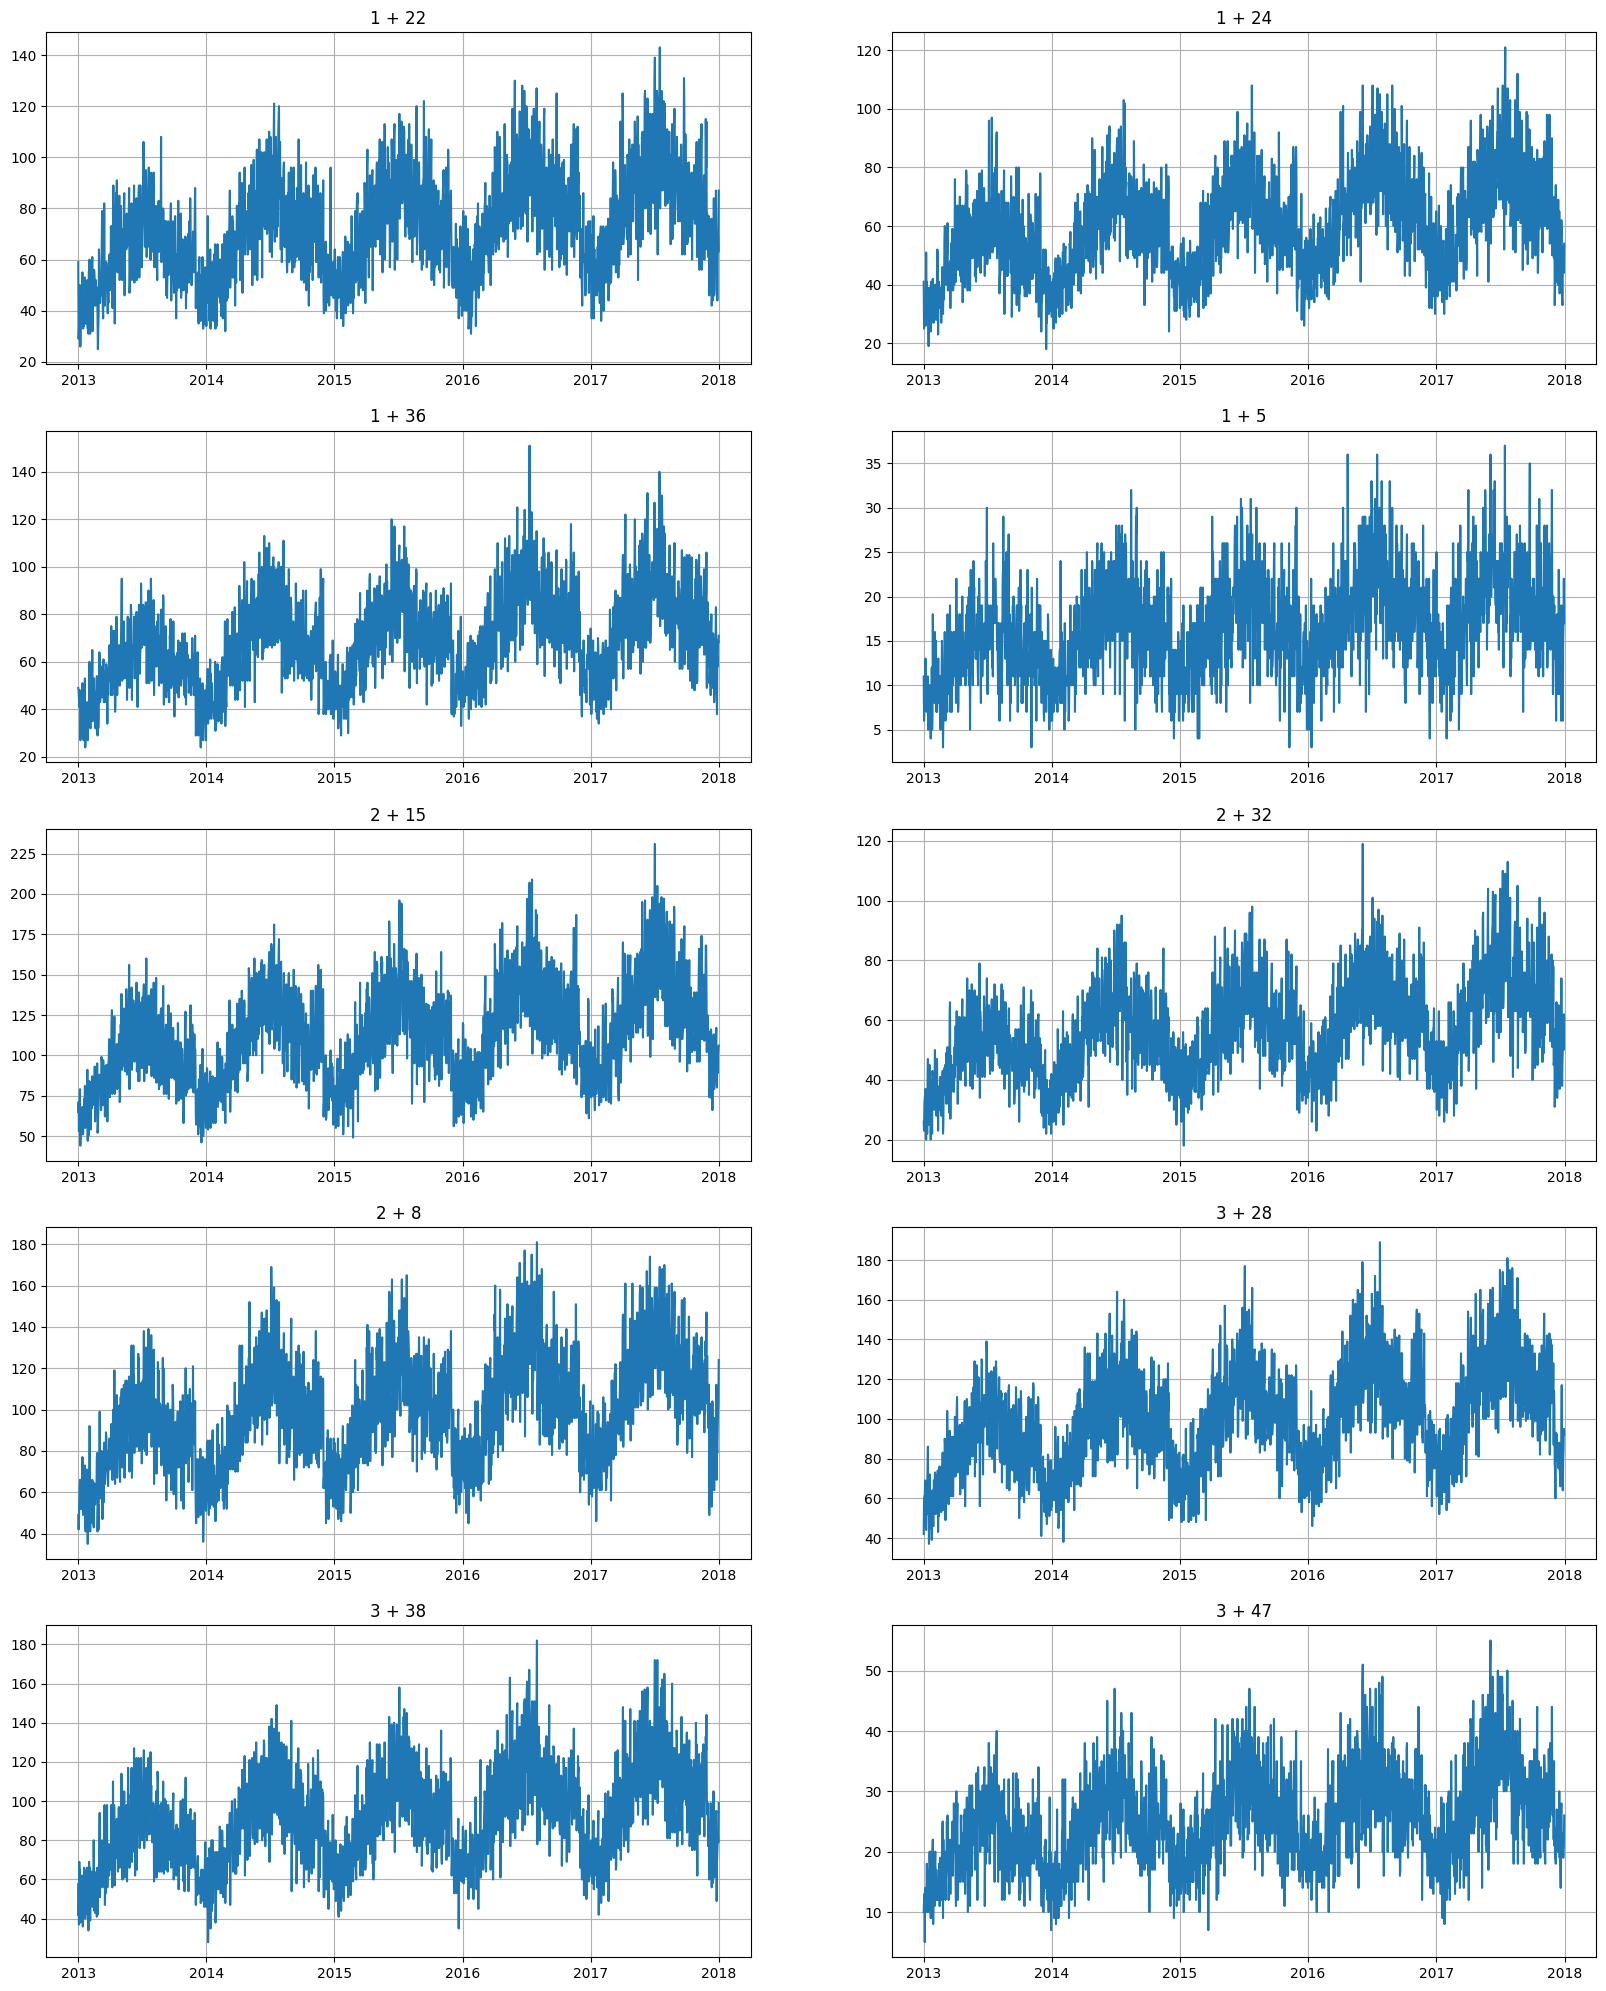

In [20]:
ts.plot()

In [21]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
1 + 1,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 10,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 11,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 12,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 13,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
...,...,...,...,...,...,...,...,...,...
3 + 50,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
3 + 6,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
3 + 7,2013-01-01,2017-12-31,1826,0,150,5,5,5,D


In [22]:
from etna.analysis import acf_plot
from etna.analysis import plot_correlation_matrix

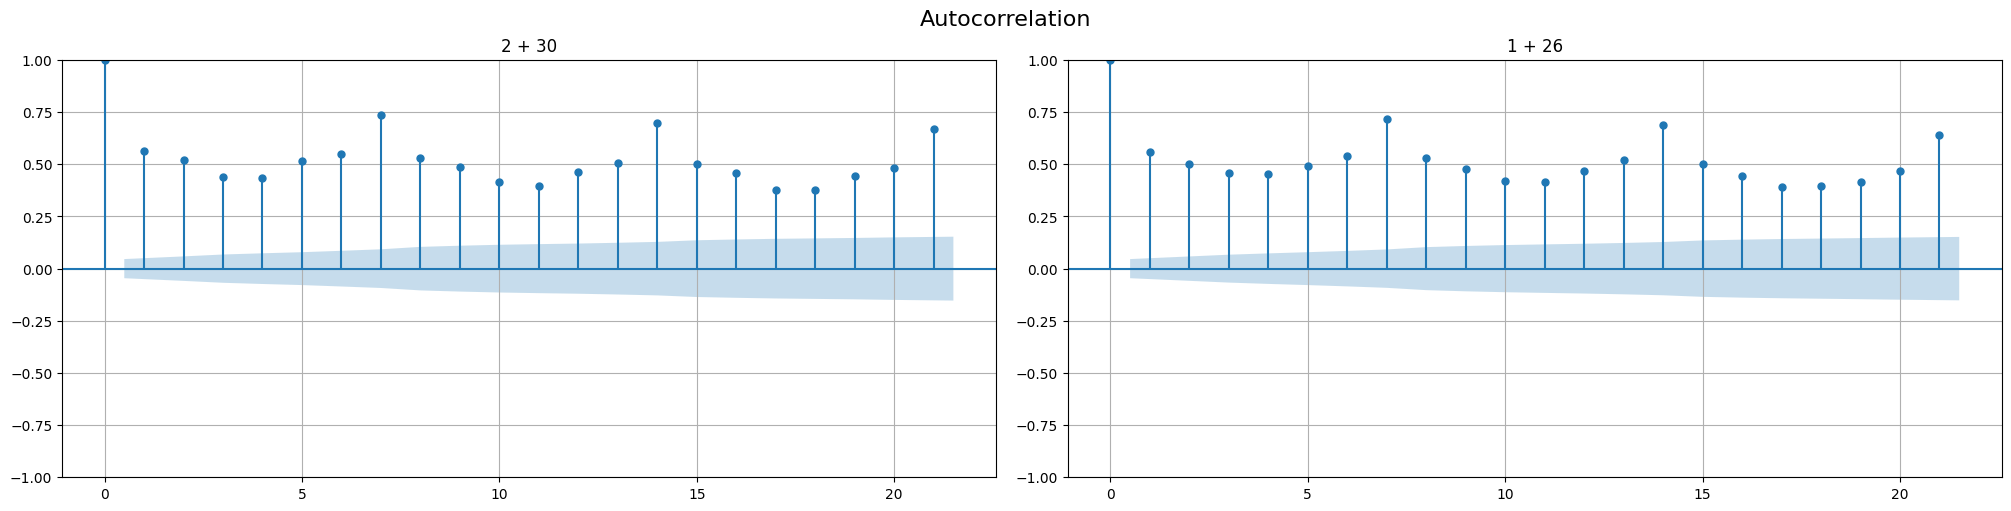

In [23]:
acf_plot(ts, lags=21, n_segments=2)

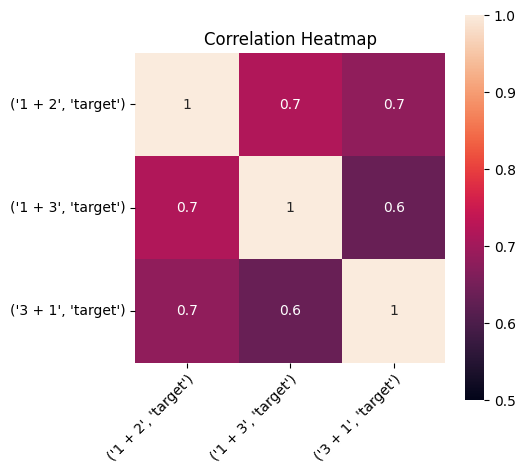

In [24]:
plot_correlation_matrix(ts, columns=['target'], segments=['1 + 2', "1 + 3", "3 + 1"],
                        method="spearman", vmin=0.5, vmax=1, figsize=(5,5))

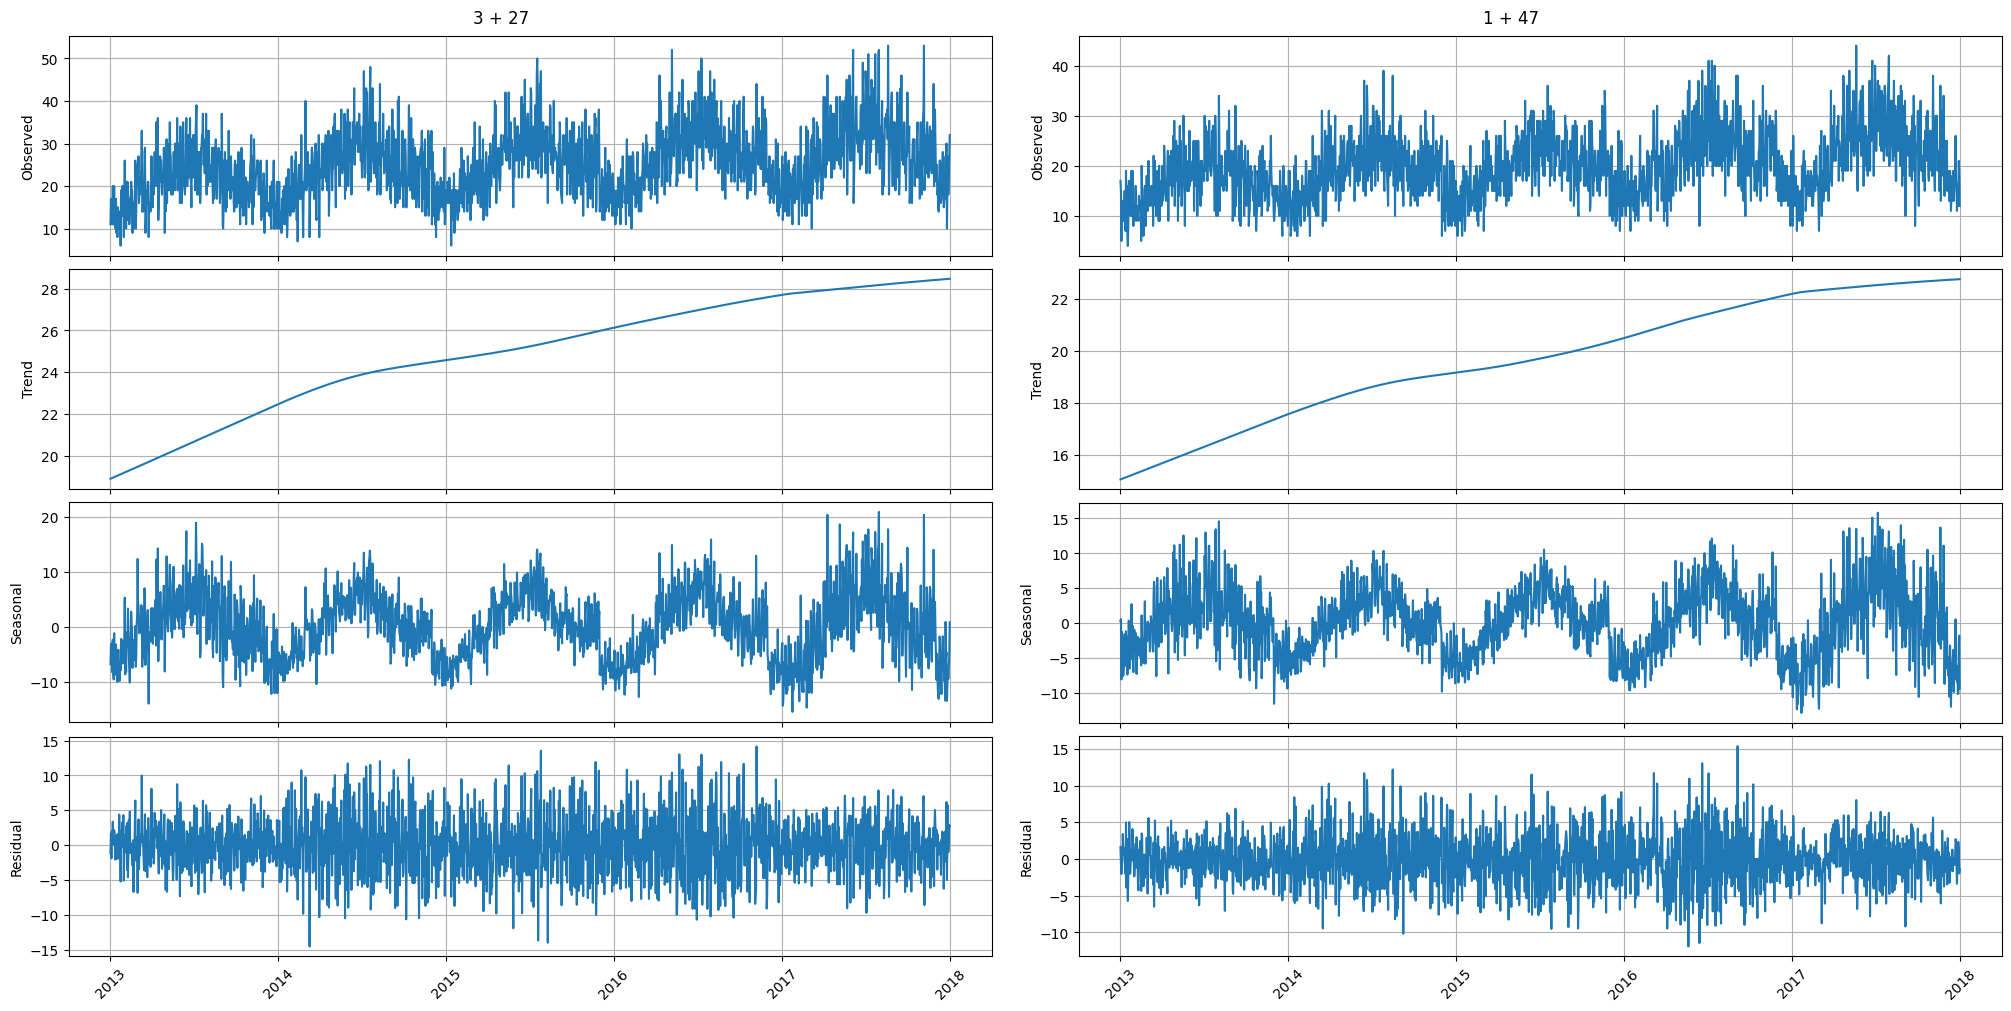

In [25]:
from etna.analysis import stl_plot

stl_plot(ts=ts, period=365, segments=SEGMENTS_TO_SHOW)

# 0. Naive Model

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 27.94174347082239


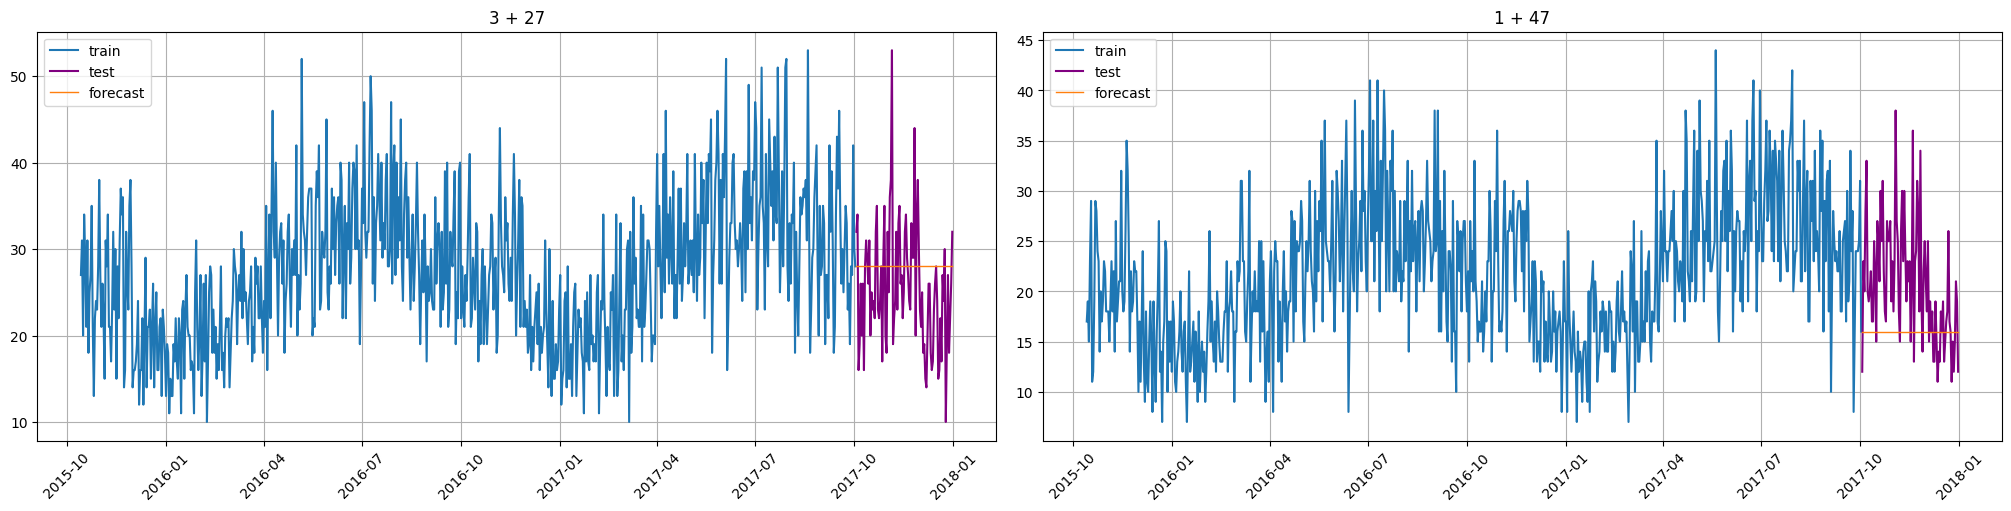

In [26]:
from etna.models import NaiveModel

naive_model_recursive_metrics = train_and_evaluate_model(
    ts=ts,
    model=NaiveModel(),
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=True,
    print_metrics=True,
    )

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 27.94174347082239


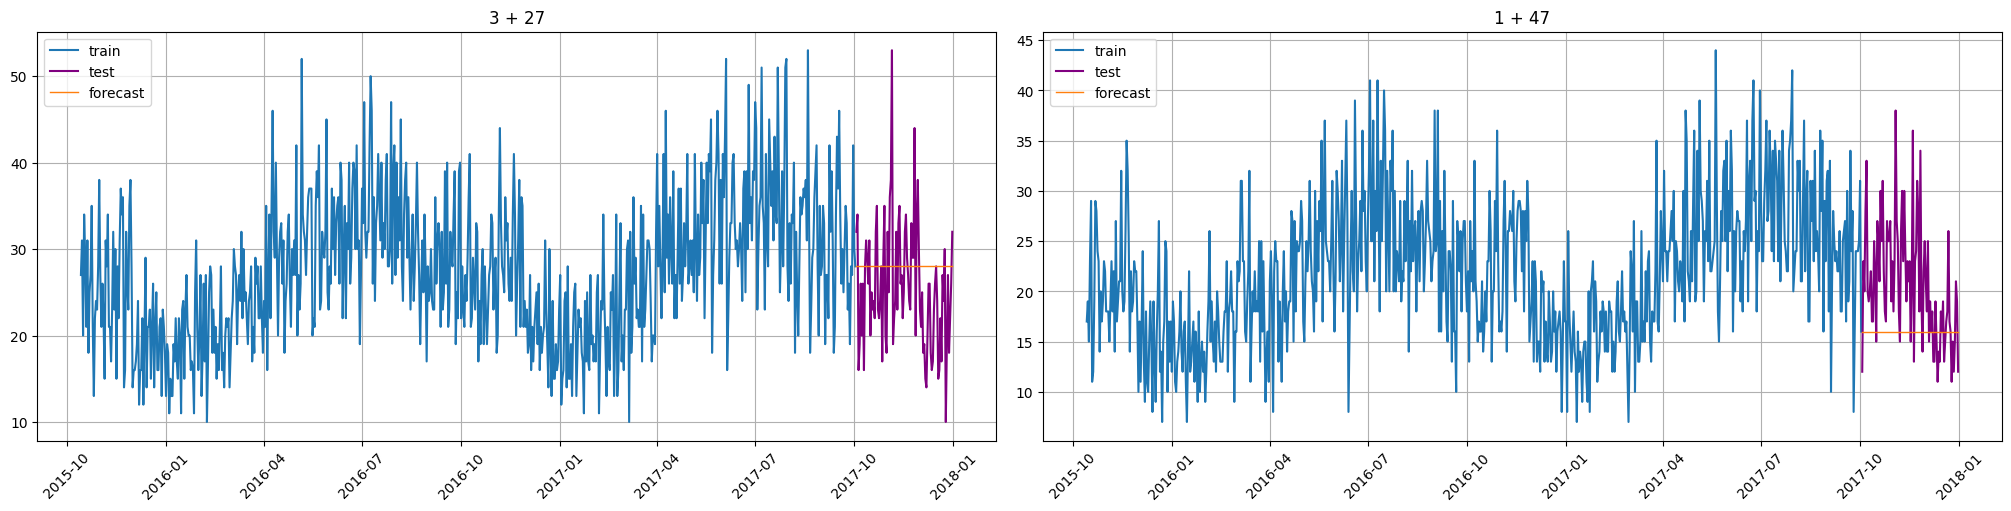

In [27]:
from etna.models import NaiveModel

naive_model_NON_recursive_metrics = train_and_evaluate_model(
    ts=ts,
    model=NaiveModel(),
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True,
    )

# 1. Linear Model

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 19.20218208442606


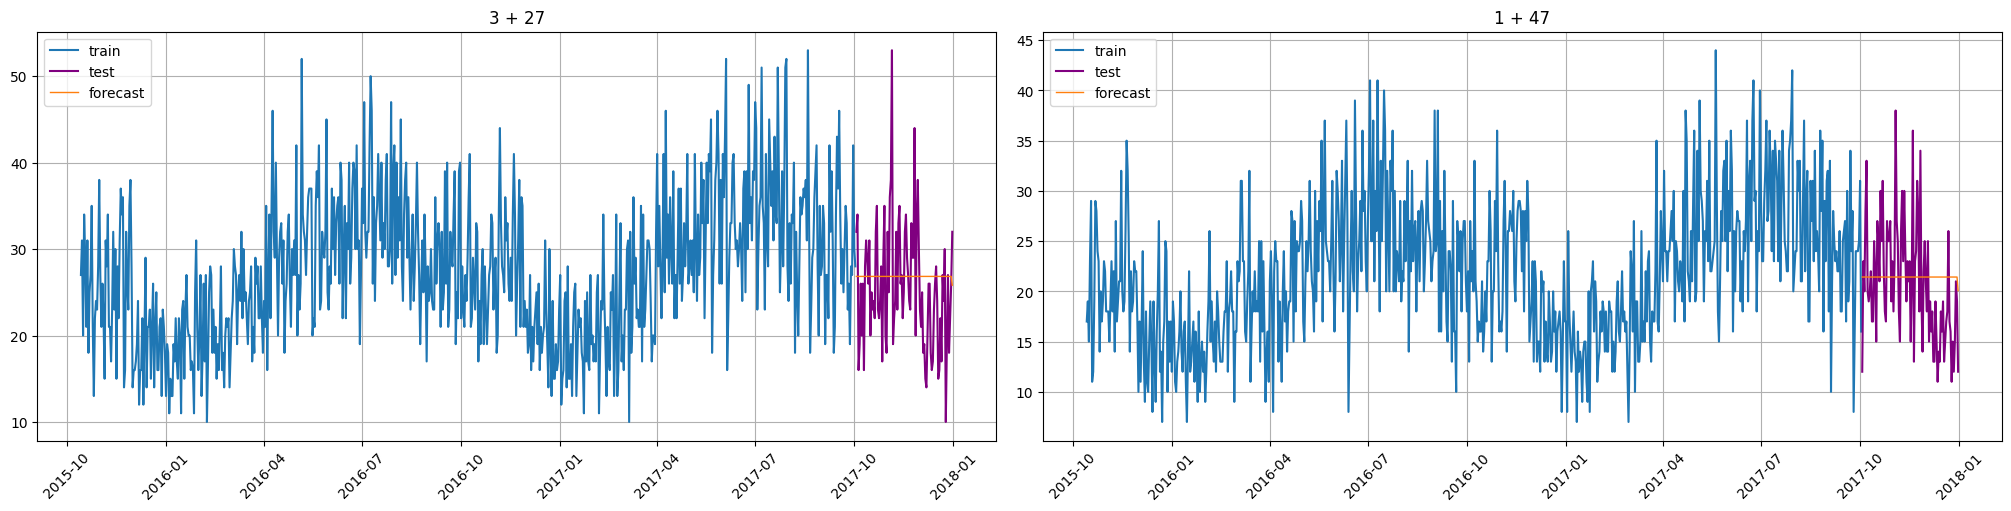

In [28]:
from etna.models import ElasticPerSegmentModel
from etna.pipeline import Pipeline
from etna.transforms import TimeSeriesImputerTransform


mean7 = MeanTransform(in_column='target',
                      window=7,
                      out_column='mean_7')

elast_transforms = [mean7]

linear_model_metrics = train_and_evaluate_model(
    ts=ts,
    model=ElasticPerSegmentModel(l1_ratio=0, alpha=0, random_state=42),
    transforms=elast_transforms,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True
)

# 2. Prophet Model

In [29]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled = True

from etna.models.prophet import ProphetModel

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 12.535072424105266


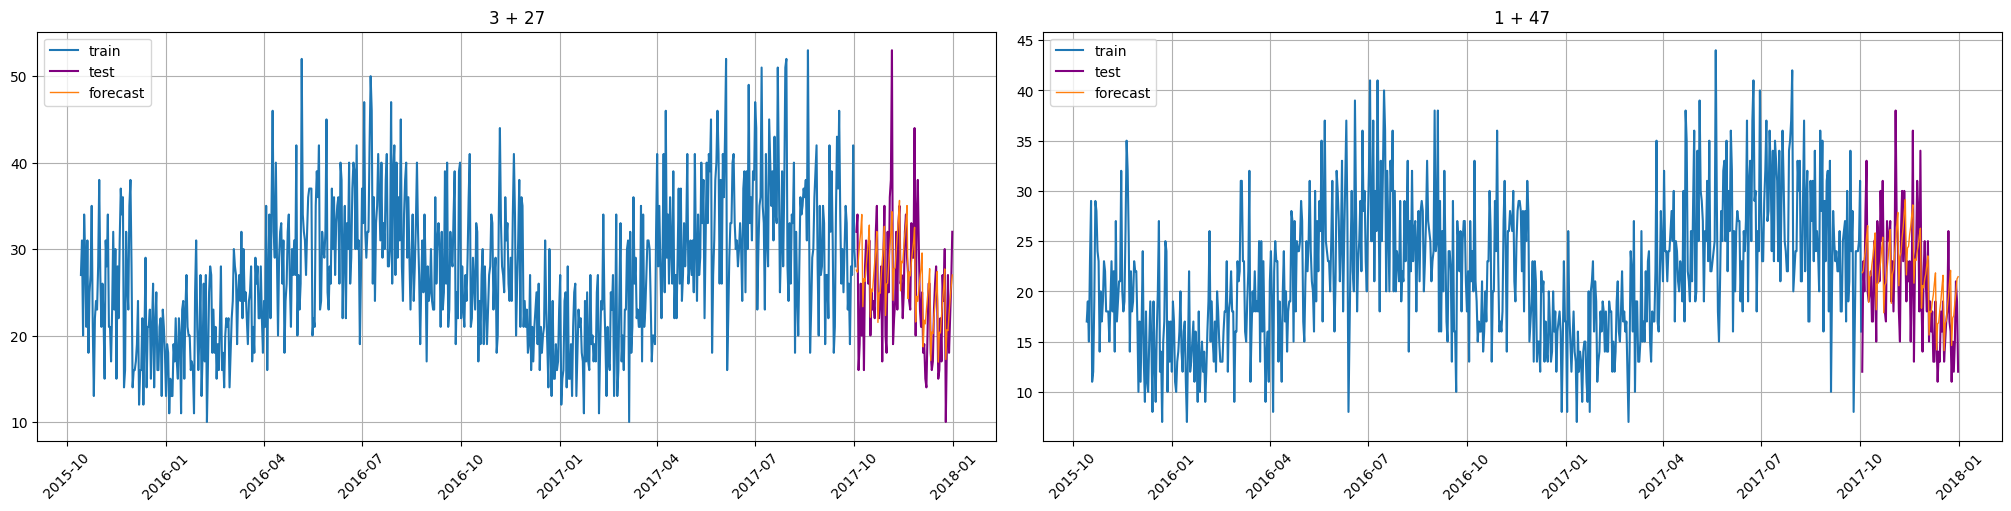

In [30]:
prophet_model = ProphetModel(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95
)

prophet_metrics = train_and_evaluate_model(
    ts=ts,
    model=prophet_model,
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True
)

In [31]:
# Улучшенная ячейка для Prophet - расширенный grid search с использованием экзогенных переменных
import numpy as np
from itertools import product
from etna.transforms import LogTransform

# ===== ЭТАП 0: Проверка данных на наличие проблем для LogTransform =====
print("=== ЭТАП 0: Проверка данных ===")

# Проверим данные на наличие нулевых и отрицательных значений
train_ts, test_ts = ts.train_test_split(test_size=HORIZON)

for segment in ts.segments:
    train_target = train_ts[:, segment, 'target'].values
    test_target = test_ts[:, segment, 'target'].values
    
    min_train = np.min(train_target)
    min_test = np.min(test_target)
    zero_train = np.sum(train_target == 0)
    zero_test = np.sum(test_target == 0)

# Определяем, нужен ли сдвиг для log transform
min_values = []
for segment in ts.segments:
    train_target = train_ts[:, segment, 'target'].values
    min_values.append(np.min(train_target))

global_min = min(min_values)
log_shift = abs(global_min) + 1 if global_min <= 0 else 0
print(f"\nGlobal min across segments: {global_min}")
print(f"Log shift needed: {log_shift}")

# ===== ЭТАП 1: Базовые параметры с разными transforms =====
print("\n=== ЭТАП 1: Тестирование разных transforms ===")

# Попробуем разные transforms
# так как данные положительные, можно использовать LogTransform
transforms_options = [
    [], 
    [LogTransform(in_column='target')], 
    [
        BoxCoxTransform(in_column='target'),
        DateFlagsTransform(
            day_number_in_week=True,
            day_number_in_month=True,
            month_number_in_year=True,
            is_weekend=True,
            out_column='date_flag'
        ),
    ],
    [
        BoxCoxTransform(in_column='target'),
        DateFlagsTransform(
            day_number_in_week=True,
            day_number_in_month=True,
            month_number_in_year=True,
            is_weekend=True,
            out_column='date_flag'
        ),
        HolidayTransform(iso_code='RU')
    ],
    [
        BoxCoxTransform(in_column='target'),
        DateFlagsTransform(
            day_number_in_week=True,
            day_number_in_month=True,
            day_number_in_year=True,
            month_number_in_year=True,
            week_number_in_month=True,
            week_number_in_year=True,
            is_weekend=True,
            out_column='date_flag'
        ),
        HolidayTransform(iso_code='RU')
    ],
]

    
print(f"Will test transforms: {transforms_options}")


base_params = {
    'growth': 'linear',
    'yearly_seasonality': True,
    'weekly_seasonality': True,
    'daily_seasonality': False,
    'seasonality_mode': 'additive',
    'changepoint_prior_scale': 0.05,
    'seasonality_prior_scale': 10.0,
    'interval_width': 0.95
}

best_smape = float('inf')
best_transforms = None
best_params = base_params.copy()

for transforms in transforms_options:
    model = ProphetModel(**base_params)
    
    segment_metrics, avg_smape = train_and_evaluate_model(
        ts=ts,
        model=model,
        transforms=transforms,
        horizon=HORIZON,
        metrics=smape,
        is_auto_regressive=False,
        print_metrics=True,
        segments_to_plot=None
    )
    
    if avg_smape < best_smape:
        best_smape = avg_smape
        best_transforms = transforms
        print(f"New best with transforms {transforms}: SMAPE = {best_smape:.4f}")

print(f"\nBest after stage 1: {best_smape:.4f}")
print(f"Best transforms: {best_transforms}")
# здесь удобно разбить ячейку, чтобы отдельно тестировать transforms до запуска тяжелых операций

=== ЭТАП 0: Проверка данных ===

Global min across segments: 1.0
Log shift needed: 0

=== ЭТАП 1: Тестирование разных transforms ===
Will test transforms: [[], [LogTransform(in_column = 'target', base = 10, inplace = True, out_column = None, )], [BoxCoxTransform(in_column = ['target'], inplace = True, out_column = None, standardize = True, mode = 'per-segment', ), DateFlagsTransform(day_number_in_week = True, day_number_in_month = True, day_number_in_year = False, week_number_in_month = False, week_number_in_year = False, month_number_in_year = True, season_number = False, year_number = False, is_weekend = True, special_days_in_week = (), special_days_in_month = (), out_column = 'date_flag', in_column = None, )], [BoxCoxTransform(in_column = ['target'], inplace = True, out_column = None, standardize = True, mode = 'per-segment', ), DateFlagsTransform(day_number_in_week = True, day_number_in_month = True, day_number_in_year = False, week_number_in_month = False, week_number_in_year = Fa

In [32]:
# ===== ЭТАП 2: Расширенный grid search =====
param_grid = {
    'changepoint_prior_scale': [
        0.05, 0.1, 0.15
    ],
    'seasonality_prior_scale': [
        80.0, 90.0, 100.0, 110.0, 120.0
    ],
    'seasonality_mode': ['additive'],
    'growth': ['linear'],
}

best_smape = float('inf')
best_params = None

# Сначала грубый поиск (coarse grid)
print("\n=== ЭТАП 2: Расширенный grid search ===")
for cps, sps, sm, growth in product(
    param_grid['changepoint_prior_scale'],
    param_grid['seasonality_prior_scale'],
    param_grid['seasonality_mode'],
    param_grid['growth']
):
    model = ProphetModel(
        growth=growth,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode=sm,
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        interval_width=0.95
    )
    
    segment_metrics, avg_smape = train_and_evaluate_model(
        ts=ts,
        model=model,
        transforms=best_transforms,
        horizon=HORIZON,
        metrics=smape,
        is_auto_regressive=False,
        print_metrics=False,
        segments_to_plot=None
    )
    
    if avg_smape < best_smape:
        best_smape = avg_smape
        best_params = {
            'changepoint_prior_scale': cps,
            'seasonality_prior_scale': sps,
            'seasonality_mode': sm,
            'growth': growth,
        }
        print(f"New best: {best_smape:.4f} with {best_params}")

print(f"\nBest after coarse search: {best_smape:.4f}")
print(f"Best params: {best_params}")



=== ЭТАП 2: Расширенный grid search ===
New best: 12.3047 with {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 80.0, 'seasonality_mode': 'additive', 'growth': 'linear'}
New best: 12.2827 with {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 80.0, 'seasonality_mode': 'additive', 'growth': 'linear'}
New best: 12.2825 with {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 110.0, 'seasonality_mode': 'additive', 'growth': 'linear'}

Best after coarse search: 12.2825
Best params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 110.0, 'seasonality_mode': 'additive', 'growth': 'linear'}


In [33]:


# ===== ЭТАП 3: Fine-tuning вокруг лучших параметров =====
print("\n=== ЭТАП 3: Fine-tuning ===")

cps_base = best_params['changepoint_prior_scale']
sps_base = best_params['seasonality_prior_scale']
sm_base = best_params['seasonality_mode']
growth_base = best_params['growth']

# Fine tuning: ±15% для непрерывных параметров
cps_min, cps_max = cps_base * 0.85, cps_base * 1.15
sps_min, sps_max = sps_base * 0.85, sps_base * 1.15

cps_range = np.linspace(cps_min, cps_max, 20)
sps_range = np.linspace(sps_min, sps_max, 20)

for cps, sps in product(cps_range, sps_range):
    model = ProphetModel(
        growth=growth_base,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode=sm_base,
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        interval_width=0.95
    )
    
    segment_metrics, avg_smape = train_and_evaluate_model(
        ts=ts,
        model=model,
        transforms=best_transforms,
        horizon=HORIZON,
        metrics=smape,
        is_auto_regressive=False,
        print_metrics=False,
        segments_to_plot=None
    )
    
    if avg_smape < best_smape:
        best_smape = avg_smape
        best_params = {
            'changepoint_prior_scale': cps,
            'seasonality_prior_scale': sps,
            'seasonality_mode': sm_base,
            'growth': growth_base,
        }
        print(f"New best after fine-tuning: {best_smape:.4f} with {best_params}")


=== ЭТАП 3: Fine-tuning ===
New best after fine-tuning: 12.2822 with {'changepoint_prior_scale': 0.09763157894736842, 'seasonality_prior_scale': 95.23684210526315, 'seasonality_mode': 'additive', 'growth': 'linear'}
New best after fine-tuning: 12.2818 with {'changepoint_prior_scale': 0.10078947368421053, 'seasonality_prior_scale': 100.44736842105263, 'seasonality_mode': 'additive', 'growth': 'linear'}
New best after fine-tuning: 12.2814 with {'changepoint_prior_scale': 0.10236842105263158, 'seasonality_prior_scale': 110.86842105263158, 'seasonality_mode': 'additive', 'growth': 'linear'}
New best after fine-tuning: 12.2812 with {'changepoint_prior_scale': 0.10868421052631579, 'seasonality_prior_scale': 121.28947368421052, 'seasonality_mode': 'additive', 'growth': 'linear'}



=== ЭТАП 4: Финальная модель ===
Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 12.281150854166002

===== FINAL RESULT =====
Best SMAPE: 12.2812
Best params: {'changepoint_prior_scale': 0.10868421052631579, 'seasonality_prior_scale': 121.28947368421052, 'seasonality_mode': 'additive', 'growth': 'linear'}
Best transforms: [BoxCoxTransform(in_column = ['target'], inplace = True, out_column = None, standardize = True, mode = 'per-segment', ), DateFlagsTransform(day_number_in_week = True, day_number_in_month = True, day_number_in_year = True, week_number_in_month = True, week_number_in_year = True, month_number_in_year = True, season_number = False, year_number = False, is_weekend = True, special_days_in_week = (), special_days_in_month = (), out_column = 'date_flag', in_column = None, ), HolidayTransform(iso_code = 'RU', mode = 'binary', out_column = None, in_column = None, )]


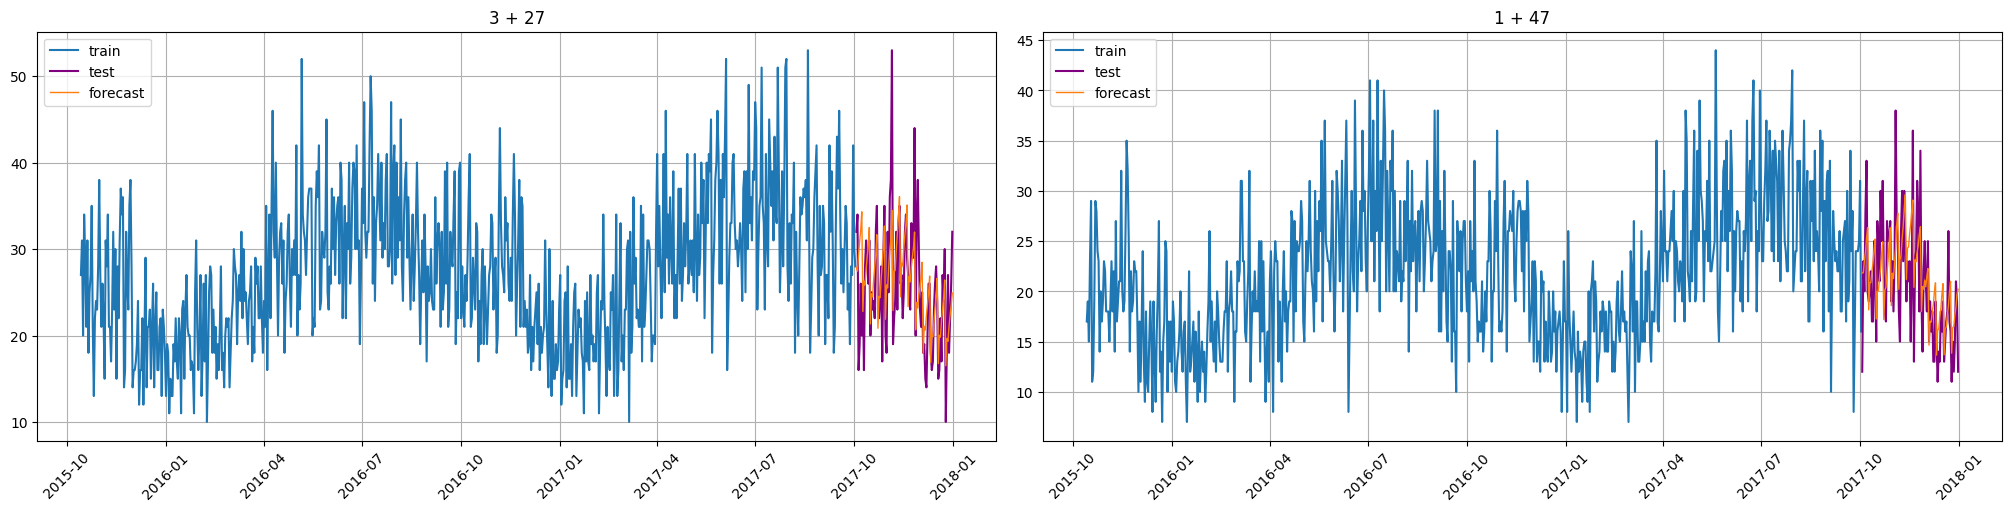

In [34]:

# ===== ЭТАП 4: Финальная модель =====
print("\n=== ЭТАП 4: Финальная модель ===")

final_model = ProphetModel(
    growth=best_params['growth'],
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode=best_params['seasonality_mode'],
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    interval_width=0.95
)

prophet_metrics = train_and_evaluate_model(
    ts=ts,
    model=final_model,
    transforms=best_transforms,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True,
    segments_to_plot=SEGMENTS_TO_SHOW
)

print(f"\n===== FINAL RESULT =====")
print(f"Best SMAPE: {prophet_metrics[1]:.4f}")
print(f"Best params: {best_params}")
print(f"Best transforms: {best_transforms}")

# 3. ARIMA Model

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 19.21513281550723


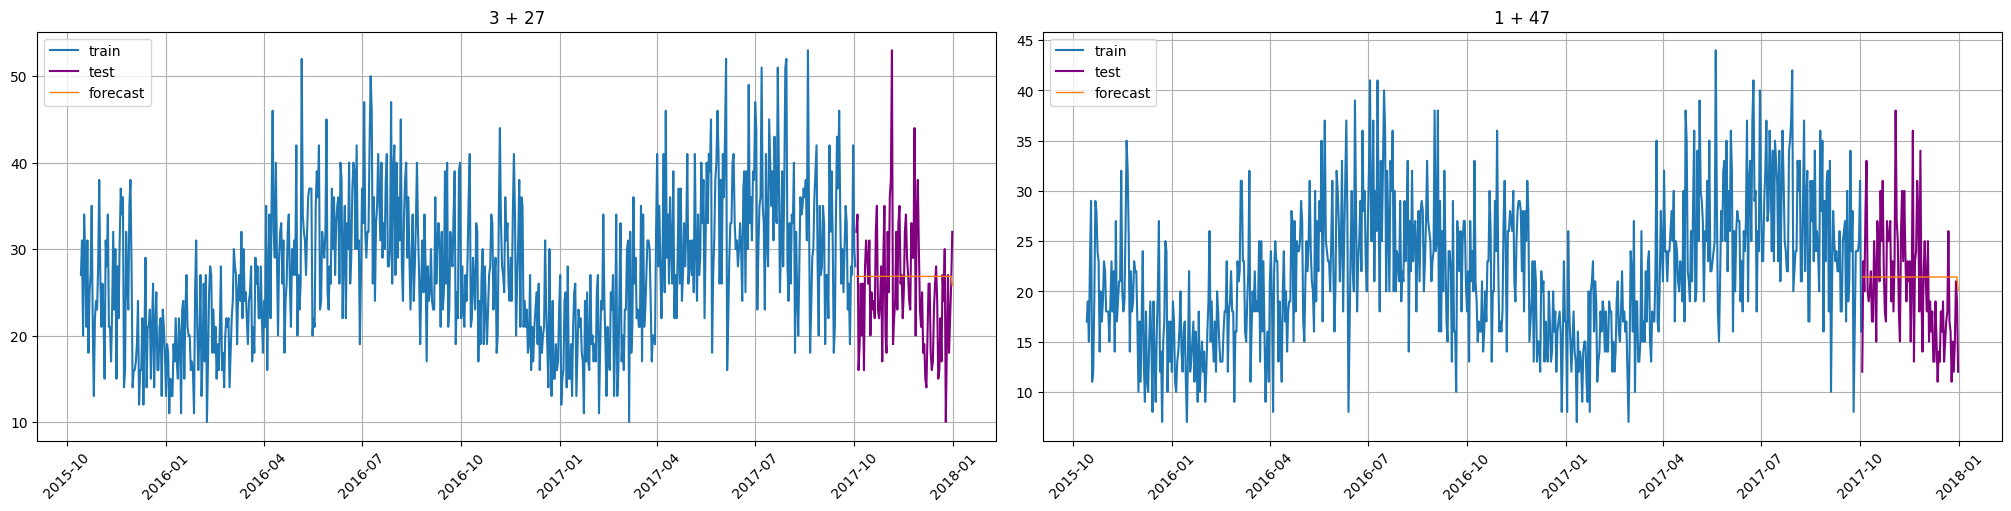

In [35]:
from etna.models import AutoARIMAModel

arima_model = AutoARIMAModel(
    seasonal=True,
    sp=7,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    m=7,
    d=None,
    seasonal_test='ocsb',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

arima_transforms = [
    StandardScalerTransform(in_column='target')
]

arima_metrics = train_and_evaluate_model(
    ts=ts,
    model=arima_model,
    transforms=arima_transforms,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True
)

# 4. CatBoost Model

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 13.819054849330538


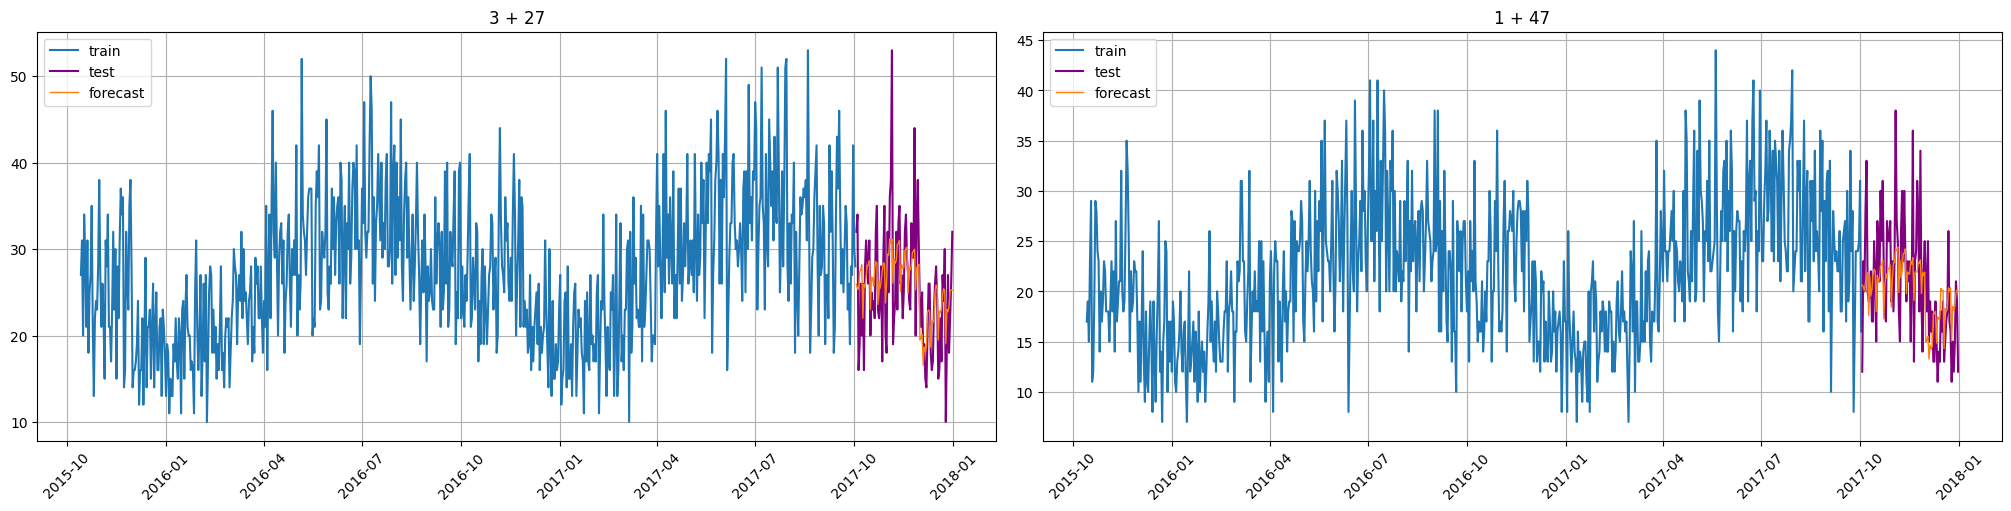

In [36]:
from etna.models import CatBoostMultiSegmentModel

catboost_transforms = [
    LagTransform(in_column='target', lags=[1, 7, 14, 28], out_column='lag'),
    MeanTransform(in_column='target', window=7, out_column='mean_7'),
    MeanTransform(in_column='target', window=14, out_column='mean_14'),
    DateFlagsTransform(day_number_in_week=True,
                      day_number_in_month=True,
                      week_number_in_year=True,
                      month_number_in_year=True,
                      is_weekend=True,
                      out_column='date_flag'),
    StandardScalerTransform(in_column=['lag_1', 'lag_7', 'lag_14', 'lag_28'])
]

catboost_model = CatBoostMultiSegmentModel(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    logging_level='Silent',
    early_stopping_rounds=100
)

catboost_metrics = train_and_evaluate_model(
    ts=ts,
    model=catboost_model,
    transforms=catboost_transforms,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=True,
    print_metrics=True
)

In [46]:
# ===== CATBOOST GRID SEARCH - ЭТАП 1: Грубый поиск =====
print("=== ЭТАП 1: Грубый Grid Search для CatBoost ===")

# Расширенные transforms (лучшие параметры из Prophet + лаги на основе сезонности)
catboost_transforms_v2 = [
    BoxCoxTransform(in_column='target', inplace=True, standardize=True, mode='per-segment'),
    LagTransform(in_column='target', lags=[1, 7, 30, 365], out_column='lag'),
    MeanTransform(in_column='target', window=7, out_column='mean_7'),
    MeanTransform(in_column='target', window=30, out_column='mean_30'),
    MeanTransform(in_column='target', window=365, out_column='mean_365'),
    DateFlagsTransform(
        day_number_in_week=True,
        day_number_in_month=True,
        day_number_in_year=True,
        week_number_in_month=True,
        week_number_in_year=True,
        month_number_in_year=True,
        season_number=False,
        year_number=False,
        is_weekend=True,
        special_days_in_week=(),
        special_days_in_month=(),
        out_column='date_flag',
        in_column=None
    ),
    HolidayTransform(iso_code='RU', mode='binary', out_column=None, in_column=None)
]

param_grid_coarse = {
    'iterations': [1000],
    'learning_rate': [0.01, 0.02],
    'depth': [6],
    'l2_leaf_reg': [1, 2, 3],
}

best_smape = float('inf')
best_params_coarse = None
results_coarse = []

total_combinations = (len(param_grid_coarse['iterations']) * 
                      len(param_grid_coarse['learning_rate']) *
                      len(param_grid_coarse['depth']) * 
                      len(param_grid_coarse['l2_leaf_reg'])
                      )

print(f"Всего комбинаций для грубого поиска: {total_combinations}")
counter = 0

for iterations, lr, depth, l2_reg in product(
    param_grid_coarse['iterations'],
    param_grid_coarse['learning_rate'],
    param_grid_coarse['depth'],
    param_grid_coarse['l2_leaf_reg'],
   ):
    counter += 1
    
    model = CatBoostMultiSegmentModel(
        iterations=iterations,
        learning_rate=lr,
        depth=depth,
        l2_leaf_reg=l2_reg,
        random_seed=42,
        logging_level='Silent',
        early_stopping_rounds=100
    )
    
    segment_metrics, avg_smape = train_and_evaluate_model(
        ts=ts,
        model=model,
        transforms=catboost_transforms_v2,
        horizon=HORIZON,
        metrics=smape,
        is_auto_regressive=True,
        print_metrics=False,
        segments_to_plot=None
    )
    
    results_coarse.append({
        'iterations': iterations,
        'learning_rate': lr,
        'depth': depth,
        'l2_leaf_reg': l2_reg,
        'smape': avg_smape
    })
    
    if avg_smape < best_smape:
        best_smape = avg_smape
        best_params_coarse = {
            'iterations': iterations,
            'learning_rate': lr,
            'depth': depth,
            'l2_leaf_reg': l2_reg,
        }
        print(f"[{counter}/{total_combinations}] New best: SMAPE = {best_smape:.4f}")
        print(f"  params: {best_params_coarse}")

print(f"\n=== Результаты грубого поиска ===")
print(f"Best SMAPE: {best_smape:.4f}")
print(f"Best params: {best_params_coarse}")

=== ЭТАП 1: Грубый Grid Search для CatBoost ===
Всего комбинаций для грубого поиска: 6
[1/6] New best: SMAPE = 12.0742
  params: {'iterations': 1000, 'learning_rate': 0.01, 'depth': 6, 'l2_leaf_reg': 1}
[2/6] New best: SMAPE = 12.0396
  params: {'iterations': 1000, 'learning_rate': 0.01, 'depth': 6, 'l2_leaf_reg': 2}
[5/6] New best: SMAPE = 11.8639
  params: {'iterations': 1000, 'learning_rate': 0.02, 'depth': 6, 'l2_leaf_reg': 2}

=== Результаты грубого поиска ===
Best SMAPE: 11.8639
Best params: {'iterations': 1000, 'learning_rate': 0.02, 'depth': 6, 'l2_leaf_reg': 2}



=== ЭТАП 3: Финальная модель CatBoostMultiSegmentModel ===
Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 11.863881936822203


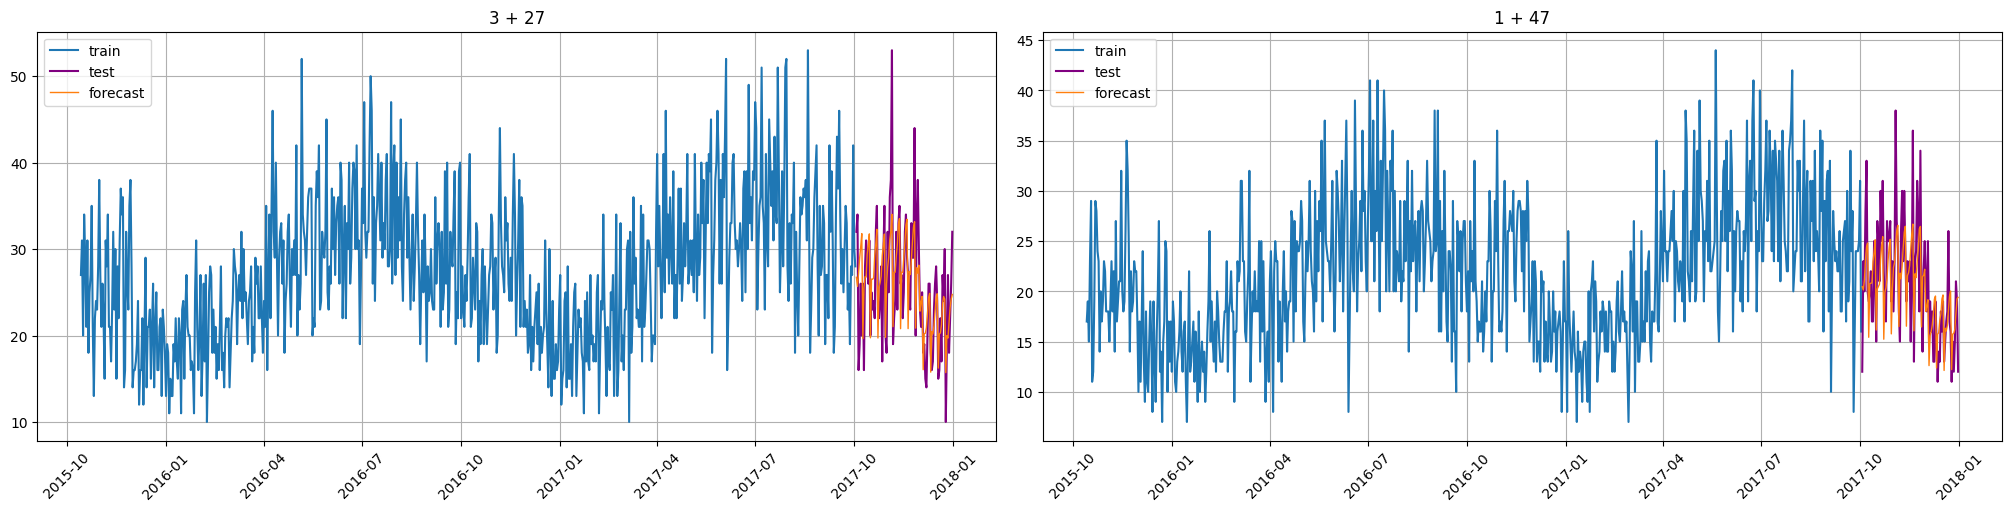

In [47]:
# ===== CATBOOST - ФИНАЛЬНАЯ МОДЕЛЬ =====
print("\n=== ЭТАП 3: Финальная модель CatBoostMultiSegmentModel ===")

# Создаем финальную модель с лучшими параметрами (включая все найденные параметры)
final_catboost_model = CatBoostMultiSegmentModel(
    iterations=best_params_coarse['iterations'],
    learning_rate=best_params_coarse['learning_rate'],
    depth=best_params_coarse['depth'],
    l2_leaf_reg=best_params_coarse['l2_leaf_reg'],
    random_seed=42,
    logging_level='Silent',
    early_stopping_rounds=100
)

# Обучаем и оцениваем
catboost_metrics = train_and_evaluate_model(
    ts=ts,
    model=final_catboost_model,
    transforms=catboost_transforms_v2,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=True,
    print_metrics=True,
    segments_to_plot=SEGMENTS_TO_SHOW
)

# Conclusion

In [48]:
model_res = {
    'naive_model_recursive_metrics': naive_model_recursive_metrics,
    'linear_model_metrics': linear_model_metrics,
    'prophet_model_metrics': prophet_metrics,
    'arima_model_metrics': arima_metrics,
    'catboost_model_metrics': catboost_metrics,
}

res = pd.DataFrame({'model': list(model_res.keys()),
                    'avg_metric': [model_res[model][1] for model in model_res.keys()],
                    'segment_metrics': [model_res[model][0] for model in model_res.keys()]})

In [49]:
res

,model,avg_metric,segment_metrics
0,naive_model_recursive_metrics,27.941743,1 + 1 50.912771 1 + 10 19.040035 1 + 11...
1,linear_model_metrics,19.202182,1 + 1 24.456839 1 + 10 18.792293 1 + 11...
2,prophet_model_metrics,12.281151,1 + 1 19.507819 1 + 10 11.448592 1 + 11...
3,arima_model_metrics,19.215133,1 + 1 24.456787 1 + 10 18.792463 1 + 11...
4,catboost_model_metrics,11.863882,1 + 1 20.201637 1 + 10 11.526851 1 + 11...


## Backtest

In [50]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

from etna.pipeline import AutoRegressivePipeline

pipe = AutoRegressivePipeline(
    model=ElasticPerSegmentModel(l1_ratio=0, alpha=0,
                                 random_state=42),
    transforms=elast_transforms,

    horizon=HORIZON)

metrics_df = pipe.backtest(
    mode='expand',
    n_folds=5,
    ts=ts,
    metrics=[smape],
    aggregate_metrics=True,
    joblib_params=dict(backend='loky'),
    n_jobs=8
)


In [51]:
metric = metrics_df['metrics']['SMAPE'].mean()

In [52]:
print(f'mean SMAPE: {metric:.4f}')

mean SMAPE: 22.9207


In [53]:
pipe_catboost = AutoRegressivePipeline(
    model=final_catboost_model,
    transforms=catboost_transforms_v2,
    horizon=HORIZON
)

catboost_metrics_df = pipe_catboost.backtest(
    mode='expand',
    n_folds=5,
    ts=ts,
    metrics=[smape],
    aggregate_metrics=True,
    joblib_params=dict(backend='loky'),
    n_jobs=8
)

print(f'CatBoost backtest mean SMAPE: {catboost_metrics_df["metrics"]["SMAPE"].mean():.4f}')

CatBoost backtest mean SMAPE: 12.5814


In [54]:
pipe_prophet = Pipeline(
    model=ProphetModel(
        growth='linear',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    ),
    transforms=[],
    horizon=HORIZON
)

prophet_metrics_df = pipe_prophet.backtest(
    mode='expand',
    n_folds=5,
    ts=ts,
    metrics=[smape],
    aggregate_metrics=True,
    joblib_params=dict(backend='loky'),
    n_jobs=-1
)

print(f'Prophet backtest mean SMAPE: {prophet_metrics_df["metrics"]["SMAPE"].mean():.4f}')

08:45:22 - cmdstanpy - INFO - Chain [1] start processing
08:45:22 - cmdstanpy - INFO - Chain [1] done processing
08:45:22 - cmdstanpy - INFO - Chain [1] start processing
08:45:22 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] done processing
08:45:23 - cmdstanpy - INFO - Chain [1] done processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] done processing
08:45:23 - cmdstanpy - INFO - Chain [1] done processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1] done processing
08:45:23 - cmdstanpy - INFO - Chain [1] done processing
08:45:23 - cmdstanpy - INFO - Chain [1] start processing
08:45:23 - cmdstanpy - INFO - Chain [1

Prophet backtest mean SMAPE: 12.4432


backtest для ARIMA на похожих задачах оценивают обычно в 15-18 %, но оценка времени исполнения на моих 32 ГБ ОП варьируется в пределах 6 - 12 часов, поэтому делать его я не стал, бесперспективно

## Задание
-  Добейтесь значения метрики **SMAPE** меньше 12% (метрика на тесте, отложенной выборке).
-  Оцените качество моделей на backtest-е.
-  Сравните рассмотренные модели между собой, объединив результаты в таблицу `res`, как это было сделано выше.
-  Опишите проделанную работу и сделайте выводы о том, как выбирали гиперпараметры, с какими сложностями столкнулись, какие модели оказались лучше и почему.
-  Используйте и подберите параметры для моделей Prophet, ARIMA, Catboost.

## Выводы:
1) при обучении моделей я провел первоначальное тестирование "моно" моделей (часть работы уже была выполнена для этого в исходном ноутбуке), ни одна из моделей не достигла уровня 12%
2) затем я отобрал только две модели - Prophet и Catboost, как самые перспективные, SMAPE остальных оказалась слишком далека от порога, кроме того, уже из опыта мне известно, что именно эти модели могут дать лучшие результаты
3) после дополнительной настройки модели Prophet  SMAPE значительно улучшился, но все же был еще далеко от порога 12%
4) модель CatBoost в чистом виде также не дала существенных результатов (это не отражено в ноутбуке, так как я удалил результаты совсем уж провальных экспериментов), но после этого я применил к ней ряд трансформеров не "с потолка", а именно тех, которые уже показали наилучшие результаты с моделью Prophet ранее, тогда удается преодолеть порог в 12% и я добился SMAPE 11.86%, таким образом, требуемый в задании результат был достигнут
5) в целом по всем моделям backtests показали удовлетворительные результаты - SMAPE чуть хуже, чем на самих обученных моделях, но в принципе, значительного переобучения не наблюдается. Разница в SMAPE на модели и на backtest есть у всех моделей, у комбинированной улучшенной модели CatBoost разница чуть выше, что говорит о том, что модель несколько склонна к переобучению, и нужно тщательно следить за ее параметрами при эксплуатации и доработке в случае дрифта данных.
6) в целом пакет etna представляет скорее академический интерес и способствует понимаю того, как проходят процессы и как работать с ней и с другими подобными пакетами (принципы везде одинаковы), или при необходимости строго сохранять использование именно пакета etna на legacy проектах. Но на данный момент пакет etna признан устаревшим, он уже недоступен в репозиториях pip для установки, его можно скачать и установить только из github проекта командой pip install git+https://github.com/etna-team/etna.git#egg=etna[all] , кроме того, etna совместим только с python  с версией не выше 3.10, на новых версиях он не работает. Поэтому для решения аналогичных задач лучше применять его адекватные замены, например, пакеты Darts, sktime, Nixtla, Google TimesFM, Amazon Chronos, TimeCopilot ( как надстройку над всеми этими моделями), самым "похожим" на etna считается Darts, в нем есть встроенные все использованные в работе модели и еще много более современных и продвинутых моделей.